# Experiment 02: Calculation of Co-channel Reuse Distance and Reuse Ratio

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 3 (frequency reuse, cluster/reuse geometry) and ICT-4203 Master Study Notes formulas used by the course.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To calculate the cluster size, co-channel reuse distance, and reuse ratio of a cellular system.

## Objectives

- Understand frequency reuse and co-channel cells.
- Generate valid hexagonal cluster sizes from shift parameters $(i,j)$.
- Calculate reuse distance $D$.
- Calculate reuse ratio $q=D/R$.
- Observe the capacity-versus-interference trade-off.

## Theory

**Frequency reuse** allows the same radio channels to be used in different cells that are separated by enough distance to keep co-channel interference within an acceptable level.

For the common hexagonal cellular model, a valid cluster size is

$$
N=i^2+ij+j^2
$$

where $i$ and $j$ are non-negative integers that describe the shift between co-channel cells.

If $R$ is the cell radius and $D$ is the distance between the centers of nearest co-channel cells, then

$$
D=R\sqrt{3N}
$$

The **co-channel reuse ratio** (also called the co-channel interference reduction factor in the course material) is

$$
q=\frac{D}{R}=\sqrt{3N}
$$

A larger $N$ gives a larger reuse distance and generally reduces co-channel interference, but the same spectrum is reused less frequently. A smaller $N$ improves capacity but requires stronger interference control.

## Procedure

1. Select cell radius $R$ and shift parameters $(i,j)$.
2. Calculate cluster size $N=i^2+ij+j^2$.
3. Calculate $q=\sqrt{3N}$.
4. Calculate $D=Rq$.
5. Repeat for several valid cluster sizes and compare the results graphically.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Configurable parameters
R_km = 1.0
i = 2
j = 1

N = i**2 + i*j + j**2
q = np.sqrt(3 * N)
D_km = R_km * q

print(f"Shift parameters (i, j) = ({i}, {j})")
print(f"Cluster size N          = {N}")
print(f"Cell radius R           = {R_km:.2f} km")
print(f"Reuse ratio q           = {q:.4f}")
print(f"Reuse distance D        = {D_km:.4f} km")

Shift parameters (i, j) = (2, 1)
Cluster size N          = 7
Cell radius R           = 1.00 km
Reuse ratio q           = 4.5826
Reuse distance D        = 4.5826 km


### Numerical Example

For $i=2$, $j=1$:

$$
N=2^2+(2)(1)+1^2=7
$$

Therefore,

$$
q=\sqrt{3(7)}=\sqrt{21}\approx4.583
$$

If $R=1$ km,

$$
D=1\times4.583\approx4.583\text{ km}
$$

In [2]:
# Generate valid cluster sizes for small i and j
valid = set()
for ii in range(0, 5):
    for jj in range(0, 5):
        if ii == 0 and jj == 0:
            continue
        valid.add(ii**2 + ii*jj + jj**2)

valid_cluster_sizes = np.array(sorted(valid))
reuse_ratios = np.sqrt(3 * valid_cluster_sizes)
reuse_distances = R_km * reuse_ratios

print("Some valid cluster sizes:", valid_cluster_sizes.tolist())

Some valid cluster sizes: [1, 3, 4, 7, 9, 12, 13, 16, 19, 21, 27, 28, 37, 48]


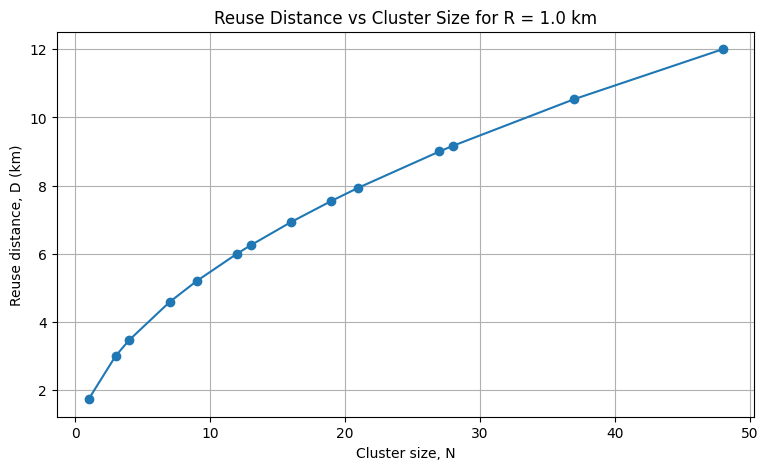

In [3]:
plt.figure(figsize=(9, 5))
plt.plot(valid_cluster_sizes, reuse_distances, marker="o")
plt.xlabel("Cluster size, N")
plt.ylabel("Reuse distance, D (km)")
plt.title(f"Reuse Distance vs Cluster Size for R = {R_km:.1f} km")
plt.grid(True)
plt.show()

**Observation:** Reuse distance increases with cluster size. Thus co-channel cells are placed farther apart when a larger cluster is used.

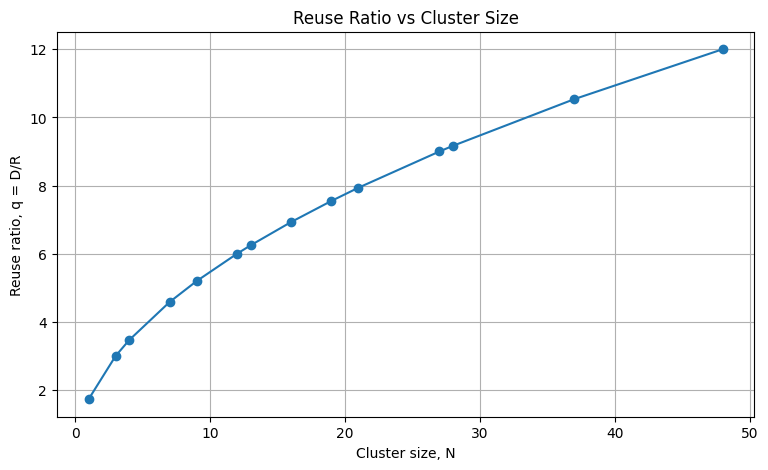

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(valid_cluster_sizes, reuse_ratios, marker="o")
plt.xlabel("Cluster size, N")
plt.ylabel("Reuse ratio, q = D/R")
plt.title("Reuse Ratio vs Cluster Size")
plt.grid(True)
plt.show()

## Result and Discussion

For the example $N=7$ and $R=1$ km, the reuse ratio is approximately **4.583** and the nearest co-channel reuse distance is approximately **4.583 km**. Increasing $N$ increases both $q$ and $D$, which improves co-channel separation but reduces how frequently a channel set can be reused.

## Conclusion

The standard hexagonal frequency-reuse equations were implemented successfully and the relation between cluster size, reuse ratio, and co-channel distance was verified.

## Viva Questions and Short Answers

1. **What is frequency reuse?**  
   Reusing the same channel set in geographically separated cells.

2. **What are co-channel cells?**  
   Cells that use the same radio frequencies.

3. **What is the reuse ratio?**  
   $q=D/R$.

4. **Why does a larger cluster reduce interference?**  
   It increases the separation between co-channel cells.

5. **What is the trade-off of increasing $N$?**  
   Lower co-channel interference but less frequent spectrum reuse and lower capacity.